# **Data Science III - Proyecto Final**


###**Clasificación automática de noticias mediante Procesamiento de Lenguaje Natural y Deep Learning**  
Desarrollo de un modelo de clasificación multiclase para la categorización automática de noticias empresariales, económicas y regulatorias

##**Presentación del proyecto**

El crecimiento de la información digital ha generado la necesidad de contar con herramientas capaces de procesar y organizar grandes volúmenes de contenido textual.

En este proyecto se propone desarrollar un modelo capaz de analizar automáticamente el contenido textual de una noticia y asignarle una categoría.

Nuestro dataset contiene noticias clasificadas en siete categorías:

- Macroeconomia
- Alianzas
- Innovacion
- Regulaciones
- Sostenibilidad
- Otra
- Reputacion

A partir del texto de las noticias se buscará entrenar un modelo de Procesamiento de Lenguaje Natural (NLP) utilizando técnicas de Deep Learning.


## **Fuente de los datos**

El dataset utilizado en este proyecto fue obtenido de Kaggle, a partir del conjunto de datos Spanish News Classification.

El dataset contiene noticias en español clasificadas en diferentes categorías temáticas y fue seleccionado debido a que permite abordar un problema de clasificación multiclase de textos, utilizando técnicas de Procesamiento de Lenguaje Natural (NLP) y Deep Learning.

Fuente original: Spanish News Classification — Kaggle: https://www.kaggle.com/datasets/kevinmorgado/spanish-news-classification

Plataforma: **Kaggle**

El dataset original fue posteriormente incorporado al repositorio de GitHub utilizado para este proyecto, con el objetivo de facilitar la reproducibilidad del análisis y del entrenamiento de los modelos.

Durante el desarrollo del proyecto se realizó un proceso de exploración, limpieza, normalización y preparación de los datos antes de utilizarlos para el entrenamiento de los modelos.


##**Motivación**

La clasificación manual de grandes volúmenes de noticias puede resultar una tarea repetitiva, costosa y poco escalable. Un sistema automático de clasificación permitiría organizar grandes cantidades de contenido de manera más rápida y consistente.

Además, la clasificación automática puede ser utilizada posteriormente para:

- organizar repositorios de noticias;
- facilitar búsquedas;
- generar estadísticas por temática;
- detectar tendencias;
- alimentar sistemas de recomendación;
- automatizar procesos de monitoreo de información.

Por lo tanto, el proyecto busca demostrar cómo las técnicas de NLP y Deep Learning pueden utilizarse para automatizar una tarea tradicionalmente realizada de manera manual.


##**Audiencia**

**Audiencia principal**

- equipos de Data Science;
- analistas de datos;
- áreas de inteligencia de negocios;
- equipos de análisis de información;
- desarrolladores de sistemas de procesamiento de noticias.

**Usuarios potenciales**

Un sistema de este tipo podría ser utilizado por organizaciones que procesan grandes volúmenes de información y necesitan clasificarla automáticamente.

La solución propuesta busca servir como una herramienta de apoyo para procesos de análisis, clasificación y gestión automática de información.

##**Contexto comercial**

Una organización dedicada al monitoreo de información empresarial recibe diariamente una gran cantidad de noticias provenientes de diferentes fuentes.

Actualmente, la clasificación temática de estos contenidos puede requerir revisión manual, generando consumo de tiempo, dependencia del criterio humano y dificultad para procesar grandes volúmenes de información.

Una solución basada en Machine Learning permitiría automatizar la categorización de noticias, facilitando:

- la organización automática de información;
- la generación de reportes por temática;
- el análisis de tendencias;
- la búsqueda inteligente de contenidos;
- la toma de decisiones basada en información estructurada.

##**Contexto analítico**

El problema planteado corresponde a un problema de aprendizaje supervisado de clasificación multiclase.

El dataset contiene noticias previamente categorizadas, donde:

- La variable de entrada será el contenido textual de la noticia (`news`).
- La variable objetivo será la categoría asignada (`Type`).
- La variable `url` será utilizada únicamente como referencia y no será considerada como característica del modelo.

El objetivo será entrenar un modelo capaz de aprender patrones lingüísticos presentes en los textos para predecir automáticamente la categoría correspondiente.


Variable predictora (X):
**`news`**


Variable objetivo (y):
**`Type`**

El modelo deberá clasificar cada noticia dentro de una de las siete categorías disponibles.

##**Pregunta principal**

Es posible desarrollar un modelo basado en Deep Learning que permita clasificar automáticamente noticias en diferentes categorías temáticas utilizando únicamente el contenido textual de las mismas?

##**Preguntas analíticas**

1. Existe suficiente información textual en las noticias para distinguir entre las diferentes categorías?

2. Qué nivel de precisión puede alcanzar un modelo de Deep Learning para clasificar las noticias?

3. Qué categorías son más fáciles y cuáles más difíciles de identificar?

4. El desbalance entre categorías afecta el desempeño del modelo?

5. El preprocesamiento del texto mejora el desempeño del modelo?

##**Hipótesis**

**Hipótesis nula (H0)**  
- El contenido textual de las noticias no proporciona información suficiente para clasificar correctamente las categorías mediante un modelo de Deep Learning.

**Hipótesis principal (H1)**  
- Un modelo de Deep Learning aplicado sobre el contenido textual de las noticias puede aprender patrones lingüísticos suficientes para clasificarlas automáticamente en sus respectivas categorías con un desempeño superior al de una clasificación aleatoria.

**Hipótesis secundaria (H2)**  
- El preprocesamiento adecuado del texto mejora el desempeño del modelo de clasificación.

**Hipótesis secundaria (H3)**  
- Las categorías con menor cantidad de ejemplos presentan un desempeño inferior debido al desbalance del dataset.



##**Objetivo general**  
Desarrollar y evaluar un modelo de Deep Learning basado en técnicas de Procesamiento de Lenguaje Natural capaz de clasificar automáticamente noticias en diferentes categorías temáticas a partir de su contenido textual.

##**Objetivos específicos**

1. Explorar y comprender el dataset utilizado para el proyecto.
2. Identificar y tratar problemas de calidad de datos, incluyendo registros duplicados y posibles inconsistencias.
3. Analizar la distribución de las categorías y determinar la existencia de desbalance de clases.
4. Preprocesar el contenido textual de las noticias mediante técnicas de NLP.
5. Preparar los datos para el entrenamiento del modelo.
6. Desarrollar un modelo de Deep Learning para la clasificación multiclase.
7. Entrenar y evaluar el modelo utilizando métricas apropiadas.
8. Analizar los resultados obtenidos, incluyendo el desempeño por categoría.
9. Determinar las limitaciones del modelo y posibles líneas de mejora.


#Análisis exploratorio de los datos

**Importación de librerías**

In [426]:
# MANIPULACIÓN Y ANÁLISIS DE DATOS
import pandas as pd
import numpy as np

# EXPRESIONES REGULARES
import re

# GENERACIÓN DE NÚMEROS ALEATORIOS
import random

# VISUALIZACIÓN
import matplotlib.pyplot as plt
import seaborn as sns

# SCIKIT-LEARN
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# TENSORFLOW / KERAS
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# CONFIGURACIÓN DE VISUALIZACIÓN
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)


# ESTABILIDAD
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
# Se establece un valor fijo para controlar los procesos aleatorios utilizados por Python, NumPy y TensorFlow
# Esto permite obtener resultados reproducibles al volver a ejecutar el modelo bajo las mismas condiciones


**Lectura del dataset desde GitHub**

In [427]:
# URL del dataset
URL_GITHUB = "https://raw.githubusercontent.com/Diegoagodoy/proyecto_final_data_science_III/refs/heads/main/df_total.csv"
URL_DRIVE = "https://docs.google.com/spreadsheets/d/e/2PACX-1vToE56PPIFipIT9TCy2lM-T7R6A8vbBz63aA_jt7FpacUGae2N_UF14Rsmwscf8txJogv2FOMBPvMdI/pub?output=csv"
URL_GITLAB = "https://gitlab.com/api/v4/projects/diego-group3265234%2Fproyecto_final_data_science_iii/repository/files/df_total.csv/raw?ref=main"

# Lectura del dataset
df = pd.read_csv(URL_GITHUB)

# Verificación inicial
print("Cantidad de registros:", len(df))
print("Cantidad de columnas:", len(df.columns))

Cantidad de registros: 1217
Cantidad de columnas: 3


**Dimensiones**

In [428]:
# Dimensiones del dataset
filas, columnas = df.shape

print("Cantidad de registros:", filas)
print("Cantidad de columnas:", columnas)
print("Dimensiones del dataset:", df.shape)

Cantidad de registros: 1217
Cantidad de columnas: 3
Dimensiones del dataset: (1217, 3)


**Primeras observaciones**

In [429]:
# Primeras observaciones del dataset
display(df.head())

,url,news,Type
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresarial para el desarrollo sostenible el director de sostenibilidad y clientes globales de BBVA en Colomb...,Otra
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domingo que buscará una cooperación más estrecha con su par estadounidense y que apoyará las salidas a bo...,Regulaciones
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como lo es la aviación Viva presentó su avión rosado A320NEO que apuesta por la equidad de género la luc...,Alianzas
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encadena su decimoquinta tasa positiva consecutiva. La inflación publicada por el INE se ha mantenido igual...,Macroeconomia
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión número 56 de la Convención Bancaria. Este será el primer encuentro de los banqueros del país con el p...,Otra


**Tipos de datos**

In [430]:
# Tipos de datos de las variables
display(df.dtypes)

,0
url,object
news,object
Type,object


**Información general**

In [431]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1217 entries, 0 to 1216
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   url     1217 non-null   object
 1   news    1217 non-null   object
 2   Type    1217 non-null   object
dtypes: object(3)
memory usage: 28.7+ KB


**Valores nulos**

In [432]:
# Cantidad de valores nulos por columna
nulos = df.isnull().sum()

display(nulos)

,0
url,0
news,0
Type,0


In [433]:
# Mostrar los registros con news nulo
display(
    df.loc[df["news"].isna(), ["url", "news", "Type"]]
)

,url,news,Type


**Duplicados**

In [434]:
# Cantidad de registros duplicados
duplicados = df.duplicated().sum()

print("Cantidad de registros duplicados:", duplicados)

Cantidad de registros duplicados: 75


In [435]:
# Visualización de los registros duplicados
df_duplicados = df[df.duplicated(keep=False)].sort_values(
    by=["url", "news", "Type"]
)

print("Cantidad de registros involucrados en duplicaciones:", len(df_duplicados))

display(df_duplicados)

Cantidad de registros involucrados en duplicaciones: 145


,url,news,Type
511,https://www.bbva.com/es/ar/bbva-en-argentina-celebra-10-anos-de-cyber-monday-con-promociones-exclusivas-para-sus-clientes/,"Viajes y turismo, indumentaria, tecnología y cuidado personal son algunas de los rubros que BBVA suma al evento comercial ‘online’ más importante ...",Innovacion
571,https://www.bbva.com/es/ar/bbva-en-argentina-celebra-10-anos-de-cyber-monday-con-promociones-exclusivas-para-sus-clientes/,"Viajes y turismo, indumentaria, tecnología y cuidado personal son algunas de los rubros que BBVA suma al evento comercial ‘online’ más importante ...",Innovacion
116,https://www.bbva.com/es/ar/claves-para-operar-en-canales-digitales-de-bbva-como-obtenerlas/,Las contraseñas fáciles de recordar pero difícil de hackear son la medida de seguridad más eficaz. BBVA cuenta con variadas claves de seguridad qu...,Innovacion
738,https://www.bbva.com/es/ar/claves-para-operar-en-canales-digitales-de-bbva-como-obtenerlas/,Las contraseñas fáciles de recordar pero difícil de hackear son la medida de seguridad más eficaz. BBVA cuenta con variadas claves de seguridad qu...,Innovacion
921,https://www.bbva.com/es/ar/como-sumar-las-tarjetas-bbva-a-apple-pay-en-iphone-y-apple-watch/,"Cada vez existen más formas de pago sin contacto que facilitan las operaciones y lo hacen de una forma segura. En esta nota, BBVA explica el paso ...",Innovacion
...,...,...,...
987,https://www.bbva.com/es/valora-coches-de-bbva-alcanza-mas-de-dos-millones-de-accesos-en-dos-anos-y-medio/,"Desde su lanzamiento en febrero de 2020 y a cierre de julio, Valora Coches ha registrado más de dos millones de visitas. La herramienta, pionera e...",Innovacion
323,https://www.bbva.com/es/venture-debt-la-formula-de-financiacion-alternativa-al-capital-riesgo-para-impulsar-el-ecosistema-startup/,"El ‘venture capital’, o capital riesgo, no es la única herramienta con la que cuentan los emprendedores para financiar el crecimiento de sus empre...",Innovacion
847,https://www.bbva.com/es/venture-debt-la-formula-de-financiacion-alternativa-al-capital-riesgo-para-impulsar-el-ecosistema-startup/,"El ‘venture capital’, o capital riesgo, no es la única herramienta con la que cuentan los emprendedores para financiar el crecimiento de sus empre...",Innovacion
448,https://www.bbva.com/es/venture-debt-la-formula-de-financiacion-alternativa-al-capital-riesgo-para-impulsar-el-ecosistema-startup/,"El ‘venture capital’, o capital riesgo, no es la única herramienta con la que cuentan los emprendedores para financiar el crecimiento de sus empre...",Innovacion


**Valores únicos**

In [436]:
# Cantidad de valores únicos por columna
valores_unicos = df.nunique()

display(valores_unicos)

,0
url,1101
news,1138
Type,7


In [437]:
# Valores únicos de la variable objetivo
categorias = df["Type"].unique()

print("Cantidad de categorías:", len(categorias))
print("\nCategorías:")

for categoria in sorted(categorias):
    print("-", categoria)

Cantidad de categorías: 7

Categorías:
- Alianzas
- Innovacion
- Macroeconomia
- Otra
- Regulaciones
- Reputacion
- Sostenibilidad


**Distribución de Type**


In [438]:
# Cantidad de registros por categoría
distribucion_type = df["Type"].value_counts()

display(distribucion_type)

,count
Type,
Macroeconomia,340
Alianzas,247
Innovacion,195
Regulaciones,142
Sostenibilidad,137
Otra,130
Reputacion,26


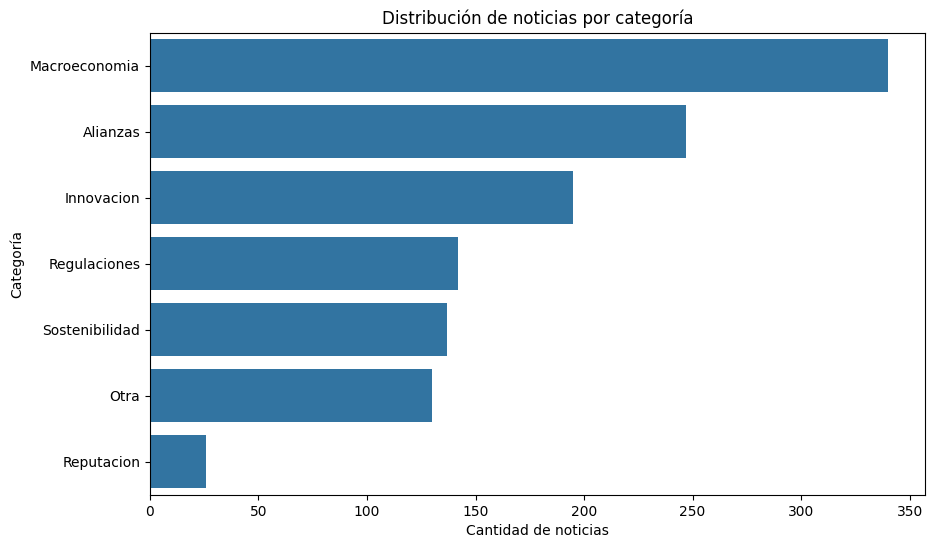

In [439]:
# Gráfico de distribución de categorías
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="Type",
    order=df["Type"].value_counts().index
)

plt.title("Distribución de noticias por categoría")
plt.xlabel("Cantidad de noticias")
plt.ylabel("Categoría")

plt.show()

In [440]:
# Porcentaje de cada categoría
porcentaje_type = (
    df["Type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(porcentaje_type)

,proportion
Type,
Macroeconomia,27.94
Alianzas,20.30
Innovacion,16.02
Regulaciones,11.67
Sostenibilidad,11.26
Otra,10.68
Reputacion,2.14


##**Análisis exploratorio del texto**

**Longitud de los textos en caracteres**

In [441]:
# Longitud de cada noticia en cantidad de caracteres
df["longitud_texto"] = df["news"].str.len()

display(df["longitud_texto"].describe())

,longitud_texto
count,1217.000000
mean,3189.077239
std,2226.450971
min,1.000000
25%,1618.000000
50%,2717.000000
75%,4070.000000
max,18451.000000


**Cantidad de palabras por noticia**

In [442]:
# Cantidad de palabras por noticia
df["cantidad_palabras"] = df["news"].str.split().str.len()

display(df["cantidad_palabras"].describe())

,cantidad_palabras
count,1217.000000
mean,516.549712
std,359.545475
min,0.000000
25%,265.000000
50%,445.000000
75%,667.000000
max,2964.000000


**Visualizar distribución de la cantidad de palabras**

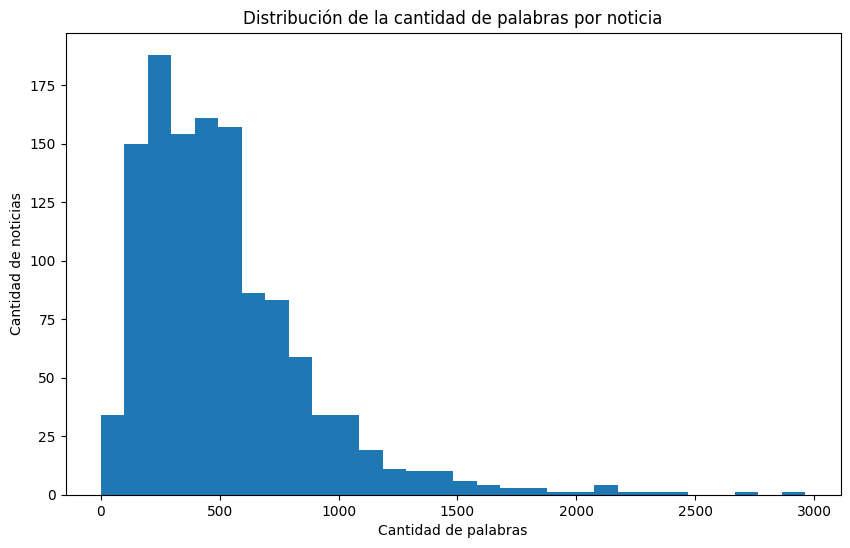

In [443]:
# Distribución de la cantidad de palabras
plt.figure(figsize=(10, 6))

plt.hist(
    df["cantidad_palabras"],
    bins=30
)

plt.title("Distribución de la cantidad de palabras por noticia")
plt.xlabel("Cantidad de palabras")
plt.ylabel("Cantidad de noticias")

plt.show()

**Identificar textos extremadamente cortos**

In [444]:
# Diez noticias con menor cantidad de palabras
textos_cortos = (
    df[["news", "Type", "cantidad_palabras"]]
    .sort_values("cantidad_palabras", ascending=True)
    .head(10)
)

display(textos_cortos)

,news,Type,cantidad_palabras
388,,Macroeconomia,0
144,,Sostenibilidad,0
241,,Macroeconomia,0
954,,Macroeconomia,0
505,"New Gen, la cuenta de inversión lanzada por BBVA Suiza cumple un año. Se trata de una cuenta 'online' destinada a un nuevo perfil de inversor que ...",Innovacion,47
1035,"New Gen, la cuenta de inversión lanzada por BBVA Suiza cumple un año. Se trata de una cuenta 'online' destinada a un nuevo perfil de inversor que ...",Innovacion,47
660,"En este capítulo de Futuro Sostenible hablamos de naturaleza. Vamos a analizar el concepto de capital natural, o lo que es lo mismo, el conjunto d...",Sostenibilidad,62
185,"Hablamos en el 'podcast' de 'Design Wedneday' con Soraya Elche, Design Researcher en BBVA, sobre los retos a los que se enfrenta la investigación ...",Innovacion,62
300,BBVA participó de Forbes Revolución Fintech Summit. El encuentro organizado por la Revista Forbes analizó el rol de la innovación financiera en la...,Innovacion,64
1075,BBVA participó de Forbes Revolución Fintech Summit. El encuentro organizado por la Revista Forbes analizó el rol de la innovación financiera en la...,Innovacion,64


- ### **Observación sobre textos vacíos**

Durante el análisis de los textos extremadamente cortos se identificaron cuatro registros cuya variable `news` contiene una cadena vacía, por lo que presentan una cantidad de palabras igual a cero.

Estos registros no fueron detectados mediante el análisis de valores nulos debido a que una cadena vacía (`""`) no es considerada un valor nulo por Pandas.

Dado que `news` constituye la variable de entrada del modelo de clasificación, estos registros serán considerados durante la etapa de limpieza y preparación de los datos

In [445]:
df.isnull().sum()

,0
url,0
news,0
Type,0
longitud_texto,0
cantidad_palabras,0


**Identificar de textos extremadamente largos**

In [446]:
# Noticias con mayor cantidad de palabras
display(
    df[["news", "Type", "cantidad_palabras"]]
    .sort_values("cantidad_palabras", ascending=False)
    .head(10)
)

,news,Type,cantidad_palabras
636,"Fue en 1972, con la Conferencia de Estocolmo, cuando se hizo visible la conciencia colectiva por el cuidado del planeta. Desde entonces se han emi...",Sostenibilidad,2964
245,"La evolución tecnológica, los procesos de digitalización de las distintas industrias y el nuevo contexto sociolaboral de teletrabajo hacen de la c...",Innovacion,2716
466,Atrevia es la consultora de comunicaciones y relaciones públicas que más presencia tiene en Latinoamérica según Carmen Sánchez Laulhé vicepreside...,Reputacion,2399
904,"La sostenibilidad se rige bajo el principio de asegurar las necesidades del presente sin comprometer las necesidades de las generaciones futuras, ...",Sostenibilidad,2306
918,El Informe Situación México correspondiente al cuarto trimestre de 2022 señala que el rebote de la actividad económica en 1S22 se desvanece a medi...,Macroeconomia,2199
48,Cuando un comité del Congreso se preparaba para interrogar públicamente a los directores ejecutivos de cuatro gigantes tecnológicos en 2020 Brad S...,Regulaciones,2126
522,"A pesar de que contribuyen con la sostenibilidad, las energías limpias y las energías renovables no son lo mismo. Las primeras serían aquellas fue...",Sostenibilidad,2114
713,"El nuevo Marco de Competencia Digital Docente ha acelerado el reloj en los centros educativos de España. De aquí a 2024, el país deberá certificar...",Sostenibilidad,2109
155,El presidente de BBVA ha concedido una entrevista al periódico vasco El Correo en la que repasa la actualidad nacional que reproducimos a continua...,Macroeconomia,2102
455,Desde instalar una ventana de doble cristal al aislamiento completo del exterior de un edificio. Las medidas de eficiencia energética en bloques d...,Sostenibilidad,2009


##**Limpieza y preparación de los datos**

**Identificación y tratamiento de registros duplicados**

- Verificar si son duplicados exactos

In [447]:
# Verificar duplicados considerando todas las columnas
duplicados_exactos = df.duplicated(
    subset=["url", "news", "Type"]
).sum()

print("Duplicados exactos:", duplicados_exactos)

Duplicados exactos: 75


- Eliminación

In [448]:
# Eliminar registros duplicados exactos
registros_antes = len(df)

df = df.drop_duplicates().copy()

registros_despues = len(df)

print("Registros antes de eliminar duplicados:", registros_antes)
print("Duplicados eliminados:", registros_antes - registros_despues)
print("Registros después de eliminar duplicados:", registros_despues)

Registros antes de eliminar duplicados: 1217
Duplicados eliminados: 75
Registros después de eliminar duplicados: 1142


- Verificación

In [449]:
# Verificar que no queden duplicados
print("Duplicados restantes:", df.duplicated().sum())

Duplicados restantes: 0


- ### **Resultado del tratamiento de duplicados**

Se identificaron 75 registros duplicados exactos en el conjunto de datos original.

Debido a que estos registros presentaban exactamente los mismos valores en las variables `url`, `news` y `Type`, fueron eliminados para evitar la repetición de información durante el entrenamiento del modelo.

El conjunto de datos pasó de 1.217 a 1.142 registros.

**Identificación y tratamiento de textos vacíos**
- Identificar textos vacíos

In [450]:
# Identificar registros con texto vacío o compuesto únicamente por espacios
mask_textos_vacios = df["news"].str.strip().eq("")

print("Cantidad de textos vacíos:", mask_textos_vacios.sum())

Cantidad de textos vacíos: 2


* Visualizar los registros antes de eliminarlos

In [451]:
# Mostrar los registros con textos vacíos
display(
    df.loc[mask_textos_vacios, ["url", "news", "Type"]]
)

,url,news,Type
144,https://www.bbva.com/es/especiales/descarga-los-monograficos-de-sostenibilidad-de-bbva/,,Sostenibilidad
241,https://www.bbva.com/es/especiales/el-camino-a-la-recuperacion-economica-evolucion-del-impacto-del-covid-19-en-el-consumo/,,Macroeconomia


- Eliminar los textos vacíos

In [452]:
# Cantidad de registros antes de la eliminación
registros_antes = len(df)

# Eliminar registros con texto vacío
df = df.loc[~mask_textos_vacios].copy()

# Cantidad de registros después
registros_despues = len(df)

print("Registros antes:", registros_antes)
print("Textos vacíos eliminados:", registros_antes - registros_despues)
print("Registros después:", registros_despues)

Registros antes: 1142
Textos vacíos eliminados: 2
Registros después: 1140


- Verificación

In [453]:
# Verificar textos vacíos restantes
textos_vacios_restantes = df["news"].str.strip().eq("").sum()

print("Textos vacíos restantes:", textos_vacios_restantes)

Textos vacíos restantes: 0


- Verificación de valores nulos

In [454]:
# Verificar valores nulos después de la limpieza
print("Valores nulos en news:", df["news"].isnull().sum())

Valores nulos en news: 0


- ### **Resultado del tratamiento de textos vacíos**

Durante el análisis exploratorio se habían identificado inicialmente 4 registros cuyo campo `news` se encontraba vacío.

Luego de realizar la eliminación de registros duplicados, 2 de estos registros fueron eliminados como consecuencia de dicha limpieza, ya que formaban parte de registros duplicados.

Posteriormente, al analizar nuevamente los textos vacíos sobre el conjunto de datos resultante, se identificaron 2 registros adicionales con el campo `news` vacío. Estos registros fueron eliminados debido a que no contienen información textual que pueda ser utilizada como variable de entrada para el modelo de clasificación.

De esta manera, el conjunto de datos pasó de 1.142 a 1.140 registros durante esta etapa.

Finalmente, se verificó que no quedaran textos vacíos ni valores nulos en la variable `news`.

**Verificación de valores inconsistentes**

- Verificar las categorías actuales

In [455]:
# Categorías actuales de la variable objetivo
print("Categorías de Type:")
display(df["Type"].value_counts())

Categorías de Type:


,count
Type,
Macroeconomia,319
Alianzas,247
Innovacion,152
Regulaciones,142
Otra,130
Sostenibilidad,124
Reputacion,26


In [456]:
# Valores únicos de Type
print("Valores únicos en Type:")
display(df["Type"].unique())

Valores únicos en Type:


array(['Otra', 'Regulaciones', 'Alianzas', 'Macroeconomia', 'Innovacion',
       'Sostenibilidad', 'Reputacion'], dtype=object)

- Espacios al principio o al final

In [457]:
# Detectar categorías con espacios al inicio o al final
categorias_con_espacios = df["Type"][
    df["Type"] != df["Type"].str.strip()
]

print(
    "Registros con espacios adicionales en Type:",
    len(categorias_con_espacios)
)

display(categorias_con_espacios)

Registros con espacios adicionales en Type: 0


,Type


- Diferencias de mayúsculas/minúsculas

In [458]:
# Comparar categorías ignorando mayúsculas/minúsculas
categorias_normalizadas = (
    df["Type"]
    .str.strip()
    .str.lower()
    .unique()
)

print("Cantidad de categorías ignorando diferencias de escritura:",
      len(categorias_normalizadas))

display(sorted(categorias_normalizadas))

Cantidad de categorías ignorando diferencias de escritura: 7


['alianzas',
 'innovacion',
 'macroeconomia',
 'otra',
 'regulaciones',
 'reputacion',
 'sostenibilidad']

- valores nulos

In [459]:
# Verificar valores nulos en la variable objetivo
print("Valores nulos en Type:", df["Type"].isnull().sum())

Valores nulos en Type: 0


- Verificación básica del contenido de **news**

In [460]:
# Cantidad de palabras por noticia
cantidad_palabras_actual = df["news"].str.split().str.len()

print(
    "Noticias con una sola palabra:",
    (cantidad_palabras_actual == 1).sum()
)

Noticias con una sola palabra: 0


- Verificar registros que no contienen texto (solo numeros)

In [461]:
# Detectar noticias compuestas únicamente por números
solo_numeros = df["news"].str.strip().str.fullmatch(r"\d+")

print(
    "Noticias compuestas únicamente por números:",
    solo_numeros.sum()
)

Noticias compuestas únicamente por números: 0


- ### **Resultado de la verificación de valores inconsistentes**

Se verificó la consistencia de la variable objetivo `Type`, sin detectar categorías duplicadas por diferencias de espacios, mayúsculas o minúsculas.

Asimismo, no se encontraron valores nulos en la variable objetivo ni registros cuyo contenido textual estuviera compuesto exclusivamente por números.

Los posibles textos de longitud reducida fueron identificados para su evaluación, pero no se eliminaron automáticamente, dado que una noticia breve no implica necesariamente que sea un registro inválido.

Por lo tanto, no se realizaron modificaciones adicionales sobre el conjunto de datos en esta etapa.

| Verificación | Resultado |
|---|---:|
| Registros con espacios adicionales en `Type` | 0 |
| Categorías inconsistentes | 0 |
| Valores nulos en `Type` | 0 |
| Noticias de una sola palabra | 0 |
| Noticias compuestas únicamente por números | 0 |


##**Limpieza y normalización del texto**


- Conversión a minúsculas

In [462]:
# Guardar ejemplos originales antes de la transformación
ejemplos_originales = df["news"].head(5).copy()

display(ejemplos_originales)

,news
0,Durante el foro La banca articulador empresarial para el desarrollo sostenible el director de sostenibilidad y clientes globales de BBVA en Colomb...
1,El regulador de valores de China dijo el domingo que buscará una cooperación más estrecha con su par estadounidense y que apoyará las salidas a bo...
2,En una industria históricamente masculina como lo es la aviación Viva presentó su avión rosado A320NEO que apuesta por la equidad de género la luc...
3,Con el dato de marzo el IPC interanual encadena su decimoquinta tasa positiva consecutiva. La inflación publicada por el INE se ha mantenido igual...
4,Ayer en Cartagena se dio inicio a la versión número 56 de la Convención Bancaria. Este será el primer encuentro de los banqueros del país con el p...


In [463]:
df["news"] = df["news"].str.lower()

In [464]:
# Visualizar los mismos ejemplos después de la transformación
display(df["news"].head(5))

,news
0,durante el foro la banca articulador empresarial para el desarrollo sostenible el director de sostenibilidad y clientes globales de bbva en colomb...
1,el regulador de valores de china dijo el domingo que buscará una cooperación más estrecha con su par estadounidense y que apoyará las salidas a bo...
2,en una industria históricamente masculina como lo es la aviación viva presentó su avión rosado a320neo que apuesta por la equidad de género la luc...
3,con el dato de marzo el ipc interanual encadena su decimoquinta tasa positiva consecutiva. la inflación publicada por el ine se ha mantenido igual...
4,ayer en cartagena se dio inicio a la versión número 56 de la convención bancaria. este será el primer encuentro de los banqueros del país con el p...


- Eliminación de espacios innecesarios

In [465]:
# Eliminar espacios al inicio y al final
df["news"] = df["news"].str.strip()

# Reemplazar múltiples espacios consecutivos por uno solo
df["news"] = df["news"].str.replace(r"\s+", " ", regex=True)

# Mostrar algunos ejemplos
display(df["news"].head(5))

,news
0,durante el foro la banca articulador empresarial para el desarrollo sostenible el director de sostenibilidad y clientes globales de bbva en colomb...
1,el regulador de valores de china dijo el domingo que buscará una cooperación más estrecha con su par estadounidense y que apoyará las salidas a bo...
2,en una industria históricamente masculina como lo es la aviación viva presentó su avión rosado a320neo que apuesta por la equidad de género la luc...
3,con el dato de marzo el ipc interanual encadena su decimoquinta tasa positiva consecutiva. la inflación publicada por el ine se ha mantenido igual...
4,ayer en cartagena se dio inicio a la versión número 56 de la convención bancaria. este será el primer encuentro de los banqueros del país con el p...


- Tratamiento de URLs

In [466]:
# Detectar noticias que contienen URLs
mask_urls = df["news"].str.contains(
    r"https?://|www\.",
    regex=True,
    case=False,
    na=False
)

print("Noticias que contienen URLs:", mask_urls.sum())

Noticias que contienen URLs: 12


In [467]:
coincidencias_urls = df.loc[mask_urls, "news"].apply(
    lambda texto: re.findall(
        r"https?://\S+|www\.\S+",
        texto,
        flags=re.IGNORECASE
    )
)

display(coincidencias_urls)

,news
101,[www.eventbrite.eseentradasteinvitamosacelebrarladiversidadylainclusion204814915927habrá]
195,[www.premionacionalaldocente.bbva.com.co]
249,[www.postdata.gov.co]
321,[www.spdji.com.]
364,[https://plataforma.hackathonbbva.com/]
471,[www.bbva.com.este]
481,[www.spdji.com.]
524,[www.superfinanciera.gov.co]
792,[www.minciencias.gov.co.]
842,[www.bbvatrader.com]


In [468]:
for indice, texto in df.loc[mask_urls, "news"].items():
    print("\n" + "=" * 100)
    print(f"Índice: {indice}")
    print(texto)


Índice: 101
el 18 de noviembre entre las 630 p.m. y las 800 p.m. se lanzará el programa inclusiones el cual es desarrollado por la agencia de los estados unidos para el desarrollo internacional usaid y la ong acdi voca con el objetivo de disminuir las barreras que enfrentan mujeres grupos étnicos personas con discapacidad adultos mayores jóvenes migrantes y la comunidad lgbtiq en entornos sociales empresariales académicos productivos y comunitarios.para estas organizaciones la inclusión es un reto pero a la vez un pilar fundamental para el desarrollo de colombia y sus procesos de reconciliación un aspecto esencial en el trabajo que realizan en el país razón por la que han creado el programa de alianzas para la reconciliación par.con el par promueven alianzas para generar inclusión e integración económica social y cultural en 24 municipios y ciudades en las que hay mayor presencia de población migrante venezolana y en los territorios pdet.según datos del ranking par 2020 y del dane cit

In [469]:
# Eliminar URLs del contenido textual

df["news"] = df["news"].str.replace(
    r"https?://\S+|www\.\S+",
    " ",
    regex=True
)

# Normalizar espacios nuevamente

df["news"] = df["news"].str.replace(
    r"\s+",
    " ",
    regex=True
).str.strip()

In [470]:
# Verificar que no queden URLs

urls_restantes = df["news"].str.contains(
    r"https?://|www\.",
    regex=True,
    case=False,
    na=False
)

print(
    "Noticias con URLs restantes:",
    urls_restantes.sum()
)

Noticias con URLs restantes: 0


- ### **Análisis de las URLs detectadas**

Se identificaron 12 noticias que contienen URLs o referencias a sitios web dentro del contenido textual.

La inspección de estos registros permitió observar que algunas URLs se encuentran correctamente delimitadas, mientras que otras aparecen concatenadas con el texto posterior de la noticia.

Por este motivo, se realizará un tratamiento específico de estas referencias antes de eliminarlas, con el objetivo de retirar únicamente la URL y conservar el contenido textual relevante para el modelo.

* Tratamiento de caracteres especiales

In [471]:
# Guardar ejemplos antes de eliminar caracteres especiales
ejemplos_antes = df["news"].head(5).copy()

display(ejemplos_antes)

,news
0,durante el foro la banca articulador empresarial para el desarrollo sostenible el director de sostenibilidad y clientes globales de bbva en colomb...
1,el regulador de valores de china dijo el domingo que buscará una cooperación más estrecha con su par estadounidense y que apoyará las salidas a bo...
2,en una industria históricamente masculina como lo es la aviación viva presentó su avión rosado a320neo que apuesta por la equidad de género la luc...
3,con el dato de marzo el ipc interanual encadena su decimoquinta tasa positiva consecutiva. la inflación publicada por el ine se ha mantenido igual...
4,ayer en cartagena se dio inicio a la versión número 56 de la convención bancaria. este será el primer encuentro de los banqueros del país con el p...


In [472]:
# Detectar noticias que contienen caracteres especiales
mask_especiales = df["news"].str.contains(
    r"[^\w\sáéíóúüñÁÉÍÓÚÜÑ]",
    regex=True,
    na=False
)

print(
    "Noticias con caracteres especiales:",
    mask_especiales.sum()
)

Noticias con caracteres especiales: 1140


In [473]:
# Mostrar algunos ejemplos
display(
    df.loc[mask_especiales, ["news", "Type"]].head(20)
)

,news,Type
0,durante el foro la banca articulador empresarial para el desarrollo sostenible el director de sostenibilidad y clientes globales de bbva en colomb...,Otra
1,el regulador de valores de china dijo el domingo que buscará una cooperación más estrecha con su par estadounidense y que apoyará las salidas a bo...,Regulaciones
2,en una industria históricamente masculina como lo es la aviación viva presentó su avión rosado a320neo que apuesta por la equidad de género la luc...,Alianzas
3,con el dato de marzo el ipc interanual encadena su decimoquinta tasa positiva consecutiva. la inflación publicada por el ine se ha mantenido igual...,Macroeconomia
4,ayer en cartagena se dio inicio a la versión número 56 de la convención bancaria. este será el primer encuentro de los banqueros del país con el p...,Otra
5,el emprendimiento del sector inmobiliario rentatop cerró una ronda de financiación por us1 millón con la inmobiliaria century 21 con la que planea...,Alianzas
6,el país tiene pendiente generar más y mejores acciones para contrarrestar la pobreza laboral y sus causas que de acuerdo con el último reporte del...,Macroeconomia
7,"en el 'podcast' tenemos el placer de entrevistar a nacho escobar, profesor en varias universidades donde introduce agile entre sus alumnos para pr...",Innovacion
8,"el factor humano, normalmente identificado como el factor más débil, ha estado influyendo y modelando la realidad digital y computacional desde su...",Innovacion
9,"los perfiles que se demandan en un banco han evolucionado, al igual que lo ha hecho la gestión del talento. los bancarios y bancarias ya no llevan...",Innovacion


In [474]:
# Eliminar caracteres especiales
# Se conservan letras, números, espacios, acentos y ñ

df["news"] = df["news"].str.replace(
    r"[^\w\sáéíóúüñÁÉÍÓÚÜÑ]",
    " ",
    regex=True
)

In [475]:
# Normalizar espacios nuevamente
df["news"] = df["news"].str.replace(
    r"\s+",
    " ",
    regex=True
).str.strip()

In [476]:
# Mostrar ejemplos después de la transformación
display(df["news"].head(5))

,news
0,durante el foro la banca articulador empresarial para el desarrollo sostenible el director de sostenibilidad y clientes globales de bbva en colomb...
1,el regulador de valores de china dijo el domingo que buscará una cooperación más estrecha con su par estadounidense y que apoyará las salidas a bo...
2,en una industria históricamente masculina como lo es la aviación viva presentó su avión rosado a320neo que apuesta por la equidad de género la luc...
3,con el dato de marzo el ipc interanual encadena su decimoquinta tasa positiva consecutiva la inflación publicada por el ine se ha mantenido igual ...
4,ayer en cartagena se dio inicio a la versión número 56 de la convención bancaria este será el primer encuentro de los banqueros del país con el pr...


In [477]:
# Verificar que no queden caracteres especiales

especiales_restantes = df["news"].str.contains(
    r"[^\w\sáéíóúüñÁÉÍÓÚÜÑ]",
    regex=True,
    na=False
)

print(
    "Noticias con caracteres especiales restantes:",
    especiales_restantes.sum()
)

Noticias con caracteres especiales restantes: 0


- Verificación del resultado de la limpieza

In [478]:
# Verificar valores nulos en news
print("Valores nulos en news:", df["news"].isna().sum())

# Verificar textos vacíos
textos_vacios = (df["news"].str.strip() == "").sum()

print("Textos vacíos:", textos_vacios)

Valores nulos en news: 0
Textos vacíos: 0


In [479]:
# Buscar caracteres especiales restantes
caracteres_especiales = df["news"].str.contains(
    r"[^\w\sáéíóúüñÁÉÍÓÚÜÑ]",
    regex=True,
    na=False
)

print(
    "Noticias con caracteres especiales:",
    caracteres_especiales.sum()
)

Noticias con caracteres especiales: 0


In [480]:
# Mostrar ejemplos del texto después de toda la limpieza
display(
    df[["news", "Type"]].head(5)
)

,news,Type
0,durante el foro la banca articulador empresarial para el desarrollo sostenible el director de sostenibilidad y clientes globales de bbva en colomb...,Otra
1,el regulador de valores de china dijo el domingo que buscará una cooperación más estrecha con su par estadounidense y que apoyará las salidas a bo...,Regulaciones
2,en una industria históricamente masculina como lo es la aviación viva presentó su avión rosado a320neo que apuesta por la equidad de género la luc...,Alianzas
3,con el dato de marzo el ipc interanual encadena su decimoquinta tasa positiva consecutiva la inflación publicada por el ine se ha mantenido igual ...,Macroeconomia
4,ayer en cartagena se dio inicio a la versión número 56 de la convención bancaria este será el primer encuentro de los banqueros del país con el pr...,Otra


**Verificación de la distribución de clases después de la limpieza**

In [481]:
# Distribución de las categorías
print("Cantidad de categorías:", df["Type"].nunique())

display(
    df["Type"].value_counts()
)

# Porcentaje de cada categoría
display(
    (df["Type"].value_counts(normalize=True) * 100)
    .round(2)
)

Cantidad de categorías: 7


,count
Type,
Macroeconomia,319
Alianzas,247
Innovacion,152
Regulaciones,142
Otra,130
Sostenibilidad,124
Reputacion,26


,proportion
Type,
Macroeconomia,27.98
Alianzas,21.67
Innovacion,13.33
Regulaciones,12.46
Otra,11.40
Sostenibilidad,10.88
Reputacion,2.28


# **Modelo de Deep Learning para clasificación de noticias**

- Separación de X e Y

In [482]:
# Variable predictora: texto de las noticias
X = df["news"]

# Variable objetivo: categoría de la noticia
y = df["Type"]

# Verificación
print("Variable predictora (X):", X.name)
print("Variable objetivo (y):", y.name)
print("Cantidad de registros en X:", len(X))
print("Cantidad de registros en y:", len(y))

Variable predictora (X): news
Variable objetivo (y): Type
Cantidad de registros en X: 1140
Cantidad de registros en y: 1140


- Codificación de las categorías

In [483]:
# Crear el codificador
encoder = LabelEncoder()

# Codificar las categorías
y_encoded = encoder.fit_transform(y)

# Mostrar la correspondencia entre categorías y valores numéricos
categorias_codificadas = dict(
    zip(encoder.classes_, encoder.transform(encoder.classes_))
)

print("Correspondencia entre categorías y valores:")
for categoria, codigo in categorias_codificadas.items():
    print(f"{categoria} → {codigo}")

Correspondencia entre categorías y valores:
Alianzas → 0
Innovacion → 1
Macroeconomia → 2
Otra → 3
Regulaciones → 4
Reputacion → 5
Sostenibilidad → 6


In [484]:
print("\nCantidad de categorías:", len(encoder.classes_))
print("Cantidad de etiquetas codificadas:", len(y_encoded))


Cantidad de categorías: 7
Cantidad de etiquetas codificadas: 1140


- División train/test

In [485]:
# División de los datos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

# Verificación de las dimensiones
print("Registros de entrenamiento:", len(X_train))
print("Registros de prueba:", len(X_test))

print("\nTotal de registros:", len(X_train) + len(X_test))

Registros de entrenamiento: 912
Registros de prueba: 228

Total de registros: 1140


In [486]:
print("Distribución en entrenamiento:")
display(
    pd.Series(y_train).value_counts().sort_index()
)

print("\nDistribución en prueba:")
display(
    pd.Series(y_test).value_counts().sort_index()
)

Distribución en entrenamiento:


,count
0,198
1,122
2,255
3,104
4,113
5,21
6,99



Distribución en prueba:


,count
0,49
1,30
2,64
3,26
4,29
5,5
6,25


- Tokenización

In [487]:
# Crear el tokenizador
tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

# Ajustar el tokenizador únicamente con los textos de entrenamiento
tokenizer.fit_on_texts(X_train)

# Convertir los textos en secuencias de números
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

print("Cantidad de palabras en el vocabulario:", len(tokenizer.word_index))
print("Cantidad de textos de entrenamiento:", len(X_train_sequences))
print("Cantidad de textos de prueba:", len(X_test_sequences))

Cantidad de palabras en el vocabulario: 26266
Cantidad de textos de entrenamiento: 912
Cantidad de textos de prueba: 228


In [488]:
# Convertir los textos a secuencias de tokens
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Analizar la longitud de las secuencias
longitudes = [len(seq) for seq in X_train_seq]

print("Longitud promedio:", np.mean(longitudes))
print("Longitud máxima:", np.max(longitudes))
print("Percentil 95:", np.percentile(longitudes, 95))

Longitud promedio: 527.1918859649123
Longitud máxima: 2433
Percentil 95: 1169.0


- Padding

In [489]:
# Longitud máxima de las secuencias
MAX_LEN = 1200

# Aplicar padding y truncamiento
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("Dimensión X_train:", X_train_pad.shape)
print("Dimensión X_test:", X_test_pad.shape)

Dimensión X_train: (912, 1200)
Dimensión X_test: (228, 1200)


- Construcción de la red neuronal

In [490]:
# Cantidad de categorías
NUM_CLASSES = y.nunique()

# Construcción del modelo
modelo = Sequential([

    Embedding(
        input_dim=len(tokenizer.word_index) + 1,
        output_dim=128
    ),

    GlobalAveragePooling1D(),

    Dense(64, activation="relu"),

    Dropout(0.5),

    Dense(NUM_CLASSES, activation="softmax")
])

In [491]:
modelo.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [492]:
modelo.build(input_shape=(None, MAX_LEN))

modelo.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 1200, 128)      │     3,362,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_9      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,370,887 (12.86 MB)

 Trainable params: 3,370,887 (12.86 MB)

 Non-trainable params: 0 (0.00 B)

- Entrenamiento


In [493]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [494]:
historial = modelo.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.2387 - loss: 1.8931 - val_accuracy: 0.2732 - val_loss: 1.8186
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.2428 - loss: 1.8375 - val_accuracy: 0.2732 - val_loss: 1.7873
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.2812 - loss: 1.7983 - val_accuracy: 0.2732 - val_loss: 1.7506
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.2936 - loss: 1.7685 - val_accuracy: 0.3989 - val_loss: 1.7143
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.2853 - loss: 1.7585 - val_accuracy: 0.4208 - val_loss: 1.6903
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.3374 - loss: 1.7205 - val_accuracy: 0.4098 - val_loss: 1.6465
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.3553 - loss: 1.6850 - val_accuracy: 0.4590 - val_loss: 1.6338
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.3635 - loss: 1.6597 - val_accuracy: 0.4809 - 

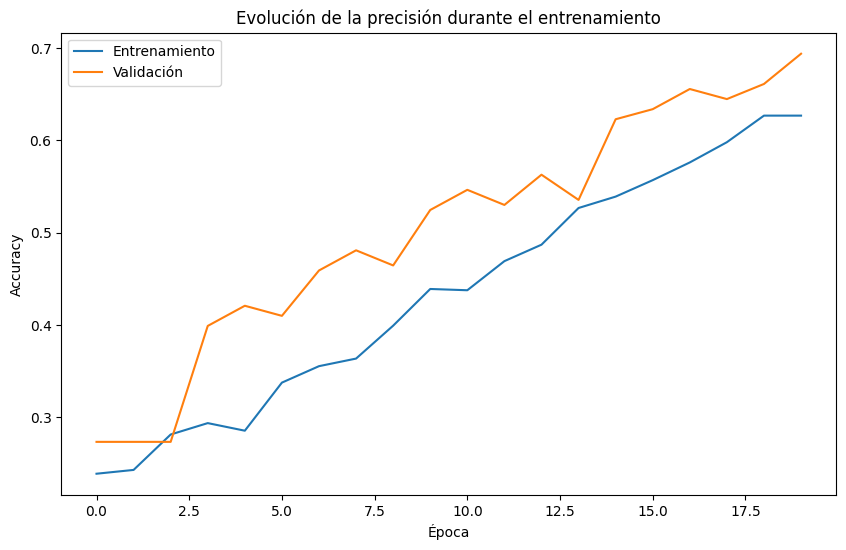

In [495]:
# Evolución de accuracy
plt.figure(figsize=(10, 6))

plt.plot(historial.history["accuracy"], label="Entrenamiento")
plt.plot(historial.history["val_accuracy"], label="Validación")

plt.title("Evolución de la precisión durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

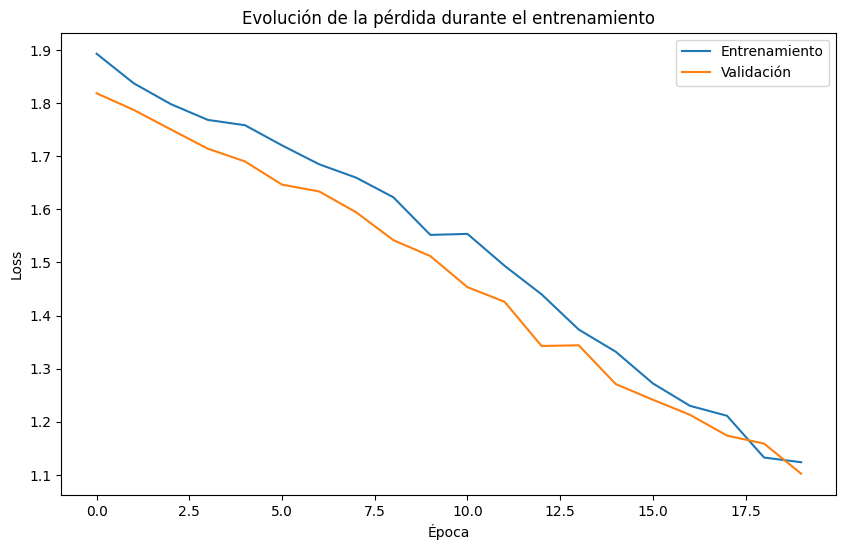

In [496]:
# Evolución de loss
plt.figure(figsize=(10, 6))

plt.plot(historial.history["loss"], label="Entrenamiento")
plt.plot(historial.history["val_loss"], label="Validación")

plt.title("Evolución de la pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.show()

- Evaluación

In [497]:
# Evaluación del modelo sobre el conjunto de prueba
resultado_test = modelo.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

print("Loss en test:", round(resultado_test[0], 4))
print("Accuracy en test:", round(resultado_test[1], 4))

Loss en test: 1.1297
Accuracy en test: 0.6667


In [498]:
# Obtener probabilidades predichas
y_pred_prob = modelo.predict(X_test_pad)

# Obtener la categoría predicha
y_pred = np.argmax(y_pred_prob, axis=1)

print("Cantidad de predicciones:", len(y_pred))

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Cantidad de predicciones: 228


- Matriz de confusión

<Figure size 1000x800 with 0 Axes>

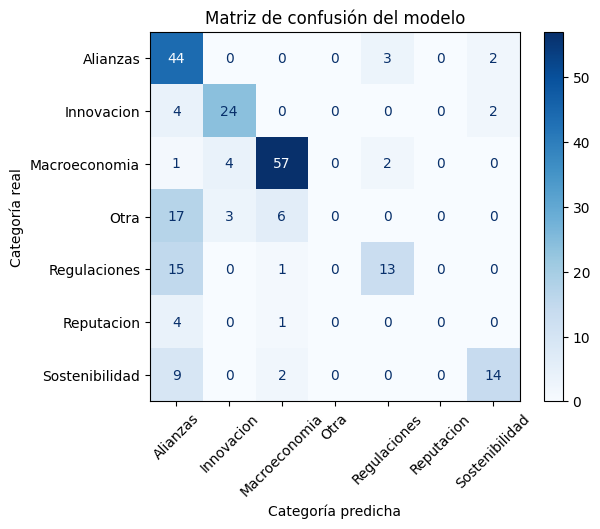

In [499]:
# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Obtener nombres de las categorías
categorias_modelo = encoder.classes_

# Visualizar matriz de confusión
plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=categorias_modelo
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Matriz de confusión del modelo")
plt.xlabel("Categoría predicha")
plt.ylabel("Categoría real")

plt.show()

- Métricas por categoría

In [500]:
# Métricas de clasificación por categoría
reporte_clasificacion = classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_,
    digits=4,
    zero_division=0
)

print(reporte_clasificacion)

                precision    recall  f1-score   support

      Alianzas     0.4681    0.8980    0.6154        49
    Innovacion     0.7742    0.8000    0.7869        30
 Macroeconomia     0.8507    0.8906    0.8702        64
          Otra     0.0000    0.0000    0.0000        26
  Regulaciones     0.7222    0.4483    0.5532        29
    Reputacion     0.0000    0.0000    0.0000         5
Sostenibilidad     0.7778    0.5600    0.6512        25

      accuracy                         0.6667       228
     macro avg     0.5133    0.5138    0.4967       228
  weighted avg     0.6184    0.6667    0.6218       228



In [501]:
print("Accuracy calculado sobre test:")

accuracy_manual = (y_test == y_pred).mean()

print(round(accuracy_manual, 4))

Accuracy calculado sobre test:
0.6667


## **Mejorando el modelo de Deep Learning**

- Modelo mejorado

In [502]:
# Construcción del modelo mejorado

modelo_mejorado = Sequential([

    Embedding(
        input_dim=len(tokenizer.word_index) + 1,
        output_dim=128
    ),

    GlobalAveragePooling1D(),

    Dense(128, activation="relu"),

    Dropout(0.4),

    Dense(64, activation="relu"),

    Dropout(0.3),

    Dense(NUM_CLASSES, activation="softmax")
])

# Construcción del modelo para visualizar su arquitectura
modelo_mejorado.build(input_shape=(None, MAX_LEN))

# Mostrar resumen
modelo_mejorado.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 1200, 128)      │     3,362,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_10     │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,387,399 (12.92 MB)

 Trainable params: 3,387,399 (12.92 MB)

 Non-trainable params: 0 (0.00 B)

- Compilación

In [503]:
# Compilación del modelo mejorado

modelo_mejorado.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

- Entrenamiento

In [504]:
# EarlyStopping para el modelo mejorado

early_stopping_mejorado = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [505]:
# Entrenamiento del modelo mejorado

historial_mejorado = modelo_mejorado.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping_mejorado],
    verbose=1
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.2195 - loss: 1.8783 - val_accuracy: 0.2732 - val_loss: 1.8090
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.2757 - loss: 1.8136 - val_accuracy: 0.2732 - val_loss: 1.7958
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.2949 - loss: 1.7965 - val_accuracy: 0.2568 - val_loss: 1.7597
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.2867 - loss: 1.7573 - val_accuracy: 0.3443 - val_loss: 1.7070
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.3114 - loss: 1.7327 - val_accuracy: 0.3716 - val_loss: 1.6790
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.3196 - loss: 1.7222 - val_accuracy: 0.4317 - val_loss: 1.6443
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.3553 - loss: 1.6666 - val_accuracy: 0.4645 - val_loss: 1.5818
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.3855 - loss: 1.6118 - val_accuracy: 0.4481 - 

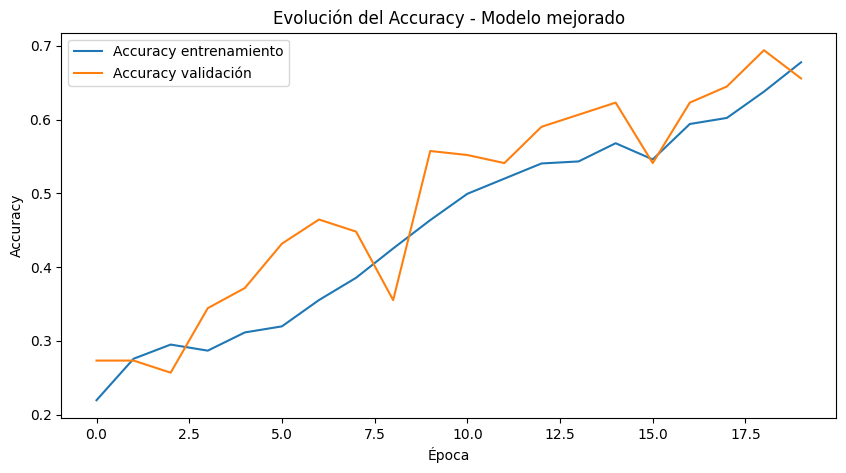

In [506]:
# Evolución del entrenamiento

plt.figure(figsize=(10, 5))

plt.plot(
    historial_mejorado.history["accuracy"],
    label="Accuracy entrenamiento"
)

plt.plot(
    historial_mejorado.history["val_accuracy"],
    label="Accuracy validación"
)

plt.title("Evolución del Accuracy - Modelo mejorado")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

- Evaluación

In [507]:
# Predicciones del modelo mejorado

y_pred_prob_mejorado = modelo_mejorado.predict(X_test_pad)

y_pred_mejorado = np.argmax(
    y_pred_prob_mejorado,
    axis=1
)

print(
    "Cantidad de predicciones:",
    len(y_pred_mejorado)
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Cantidad de predicciones: 228


In [508]:
# Accuracy del modelo mejorado

accuracy_mejorado = (
    y_test == y_pred_mejorado
).mean()

print(
    "Accuracy del modelo mejorado:",
    round(accuracy_mejorado, 4)
)

print(
    "Accuracy del modelo mejorado:",
    round(accuracy_mejorado * 100, 2),
    "%"
)

Accuracy del modelo mejorado: 0.6447
Accuracy del modelo mejorado: 64.47 %


<Figure size 1000x800 with 0 Axes>

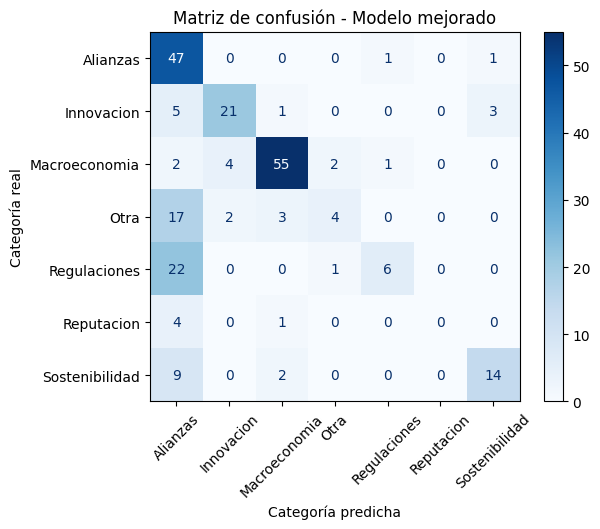

In [509]:
# Matriz de confusión del modelo mejorado

cm_mejorado = confusion_matrix(
    y_test,
    y_pred_mejorado
)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mejorado,
    display_labels=encoder.classes_
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Matriz de confusión - Modelo mejorado")
plt.xlabel("Categoría predicha")
plt.ylabel("Categoría real")

plt.show()

In [510]:
# Reporte de clasificación del modelo mejorado

reporte_mejorado = classification_report(
    y_test,
    y_pred_mejorado,
    target_names=encoder.classes_,
    zero_division=0
)

print(reporte_mejorado)

                precision    recall  f1-score   support

      Alianzas       0.44      0.96      0.61        49
    Innovacion       0.78      0.70      0.74        30
 Macroeconomia       0.89      0.86      0.87        64
          Otra       0.57      0.15      0.24        26
  Regulaciones       0.75      0.21      0.32        29
    Reputacion       0.00      0.00      0.00         5
Sostenibilidad       0.78      0.56      0.65        25

      accuracy                           0.64       228
     macro avg       0.60      0.49      0.49       228
  weighted avg       0.69      0.64      0.61       228



- Comparación con el modelo base

In [511]:
accuracy_base = accuracy_manual

print(
    "Accuracy modelo base:",
    round(accuracy_base * 100, 2),
    "%"
)

print(
    "Accuracy modelo mejorado:",
    round(accuracy_mejorado * 100, 2),
    "%"
)

Accuracy modelo base: 66.67 %
Accuracy modelo mejorado: 64.47 %


In [512]:
# Diferencia de Accuracy entre ambos modelos

diferencia_accuracy = (
    accuracy_mejorado - accuracy_base
)

print(
    "Diferencia de Accuracy:",
    round(diferencia_accuracy * 100, 2),
    "puntos porcentuales"
)

Diferencia de Accuracy: -2.19 puntos porcentuales


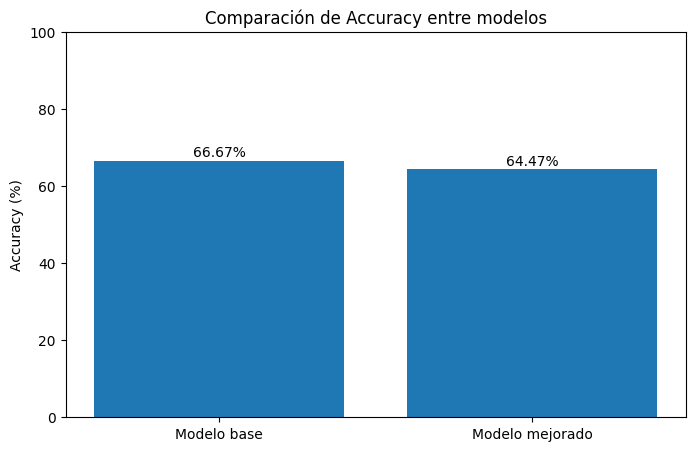

In [513]:
# Comparación de Accuracy

modelos = [
    "Modelo base",
    "Modelo mejorado"
]

accuracies = [
    accuracy_base * 100,
    accuracy_mejorado * 100
]

plt.figure(figsize=(8, 5))

plt.bar(
    modelos,
    accuracies
)

plt.ylabel("Accuracy (%)")
plt.title("Comparación de Accuracy entre modelos")
plt.ylim(0, 100)

for i, valor in enumerate(accuracies):
    plt.text(
        i,
        valor + 1,
        f"{valor:.2f}%",
        ha="center"
    )

plt.show()

In [514]:
# Tabla comparativa

comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "Modelo base",
        "Modelo mejorado"
    ],
    "Accuracy": [
        accuracy_base,
        accuracy_mejorado
    ]
})

comparacion_modelos["Accuracy (%)"] = (
    comparacion_modelos["Accuracy"] * 100
).round(2)

display(comparacion_modelos)

,Modelo,Accuracy,Accuracy (%)
0,Modelo base,0.666667,66.67
1,Modelo mejorado,0.644737,64.47


- **Análisis de resultados**

La modificación de la arquitectura permitió evaluar experimentalmente si el incremento de la capacidad de representación de la red neuronal podía mejorar el desempeño de clasificación.

Los resultados obtenidos muestran que el modelo base alcanzó un Accuracy de **66,67%**, mientras que el modelo mejorado obtuvo un Accuracy de **64,47%**. Por lo tanto, la incorporación de capas densas adicionales produjo una disminución de **2,20 puntos porcentuales** en el Accuracy.

Este resultado indica que, para este conjunto de datos y bajo las condiciones experimentales utilizadas, aumentar la complejidad de la arquitectura no produjo una mejora en el desempeño general del modelo. Por el contrario, el modelo base presentó una mejor capacidad de generalización sobre el conjunto de prueba.

El análisis de las métricas por categoría muestra que **Macroeconomia** continuó siendo una de las categorías con mejor desempeño en ambos modelos, alcanzando un F1-score de **0,87** tanto en el modelo base como en el mejorado. Esto indica que las noticias pertenecientes a esta categoría presentan patrones lingüísticos relativamente diferenciables.

En el modelo base, **Innovacion** obtuvo un F1-score de **0,79**, mientras que en el modelo mejorado descendió a **0,74**. De manera similar, **Alianzas** pasó de **0,62 a 0,61**, y **Sostenibilidad** prácticamente mantuvo su desempeño, pasando de **0,65 a 0,65**.

Un comportamiento diferente se observa en la categoría **Otra**, cuyo F1-score pasó de **0,00 en el modelo base a 0,24 en el modelo mejorado**. Esto indica que la arquitectura mejorada logró identificar algunos registros de esta categoría que el modelo base no consiguió clasificar correctamente. Sin embargo, el desempeño continúa siendo bajo.

Por otro lado, la categoría **Regulaciones** presentó una disminución importante, pasando de un F1-score de **0,55 en el modelo base a 0,32 en el modelo mejorado**. Esto evidencia que el incremento de la complejidad de la arquitectura no produjo una mejora uniforme entre las diferentes categorías.

La categoría **Reputacion** mantuvo un F1-score de **0,00 en ambos modelos**. Esta dificultad puede estar relacionada con la baja cantidad de ejemplos disponibles, ya que solamente **5 registros** pertenecen a esta categoría dentro del conjunto de prueba. Una cantidad tan reducida de ejemplos limita la capacidad del modelo para aprender patrones lingüísticos representativos de la clase.

El F1-score weighted también fue superior en el modelo base, alcanzando **0,62**, frente a **0,61** en el modelo mejorado. Este resultado es consistente con la diferencia observada en el Accuracy y refuerza la conclusión de que el modelo base presentó un mejor desempeño global.

En consecuencia, los resultados muestran que **aumentar la complejidad de la arquitectura no garantiza una mejora en el desempeño**. En este experimento, el modelo mejorado obtuvo un resultado inferior al modelo base, aunque logró mejorar parcialmente la identificación de la categoría Otra.

Este experimento permite identificar que las principales dificultades del problema no se encuentran únicamente en la arquitectura de la red neuronal, sino también en las características propias del dataset, especialmente el desbalance entre categorías y la cantidad limitada de ejemplos disponibles para algunas clases. Por lo tanto, futuras mejoras podrían enfocarse no solamente en modificar la arquitectura, sino también en aumentar la cantidad de datos y aplicar estrategias específicas para abordar las categorías minoritarias.


# **Conclusiones**

El proyecto tuvo como objetivo desarrollar y evaluar un modelo de Deep Learning capaz de clasificar automáticamente noticias en siete categorías temáticas a partir de su contenido textual.

Luego de realizar el análisis exploratorio, la limpieza de los datos, la normalización del texto y la preparación de las variables, se construyó un modelo de clasificación basado en técnicas de Procesamiento de Lenguaje Natural y Deep Learning.

El conjunto de datos utilizado quedó conformado por **1.140 noticias**, distribuidas en siete categorías. Durante la etapa de limpieza se eliminaron **75 registros duplicados exactos y 2 registros con contenido textual vacío**, evitando que información repetida o sin contenido afectara el entrenamiento del modelo. También se realizó el tratamiento de las URLs presentes en los textos, eliminándolas antes de la etapa de tokenización.

El modelo base fue construido utilizando una capa Embedding, seguida de GlobalAveragePooling1D, una capa densa de 64 neuronas y una capa Dropout, finalizando con una capa de salida Softmax para realizar la clasificación multiclase.

El modelo base obtuvo un **Accuracy de 66,67%** sobre el conjunto de prueba, compuesto por 228 noticias. Este resultado muestra que el contenido textual contiene información suficiente para que una red neuronal pueda aprender patrones asociados a las diferentes categorías.

Sin embargo, el desempeño no fue homogéneo entre las clases. **Macroeconomia** presentó el mejor desempeño, con un F1-score de **0,87**, mientras que las categorías **Otra** y **Reputacion** mostraron importantes dificultades de clasificación. En el caso de Reputacion, el F1-score fue de **0,00**.

En particular, Reputacion contó con solamente **5 registros en el conjunto de prueba**, lo que representa una limitación importante para que el modelo pueda aprender patrones representativos de esta categoría.

**Profundización mediante mejora del modelo**

Como parte de la profundización realizada para la entrega final, se desarrolló una segunda arquitectura de Deep Learning con mayor capacidad de representación.

El modelo mejorado incorporó una primera capa densa de 128 neuronas, una segunda capa densa de 64 neuronas y dos capas Dropout, manteniendo la capa Embedding y GlobalAveragePooling1D utilizadas en el modelo base.

El objetivo de esta modificación fue evaluar experimentalmente si una arquitectura más compleja podía mejorar el desempeño de clasificación.

Los resultados obtenidos fueron:

| **Modelo**      | **Accuracy** |
| --------------- | -----------: |
| Modelo base     |   **66,67%** |
| Modelo mejorado |   **64,47%** |

La modificación produjo una disminución de **2,20 puntos porcentuales** en el Accuracy.

Por lo tanto, en las condiciones experimentales utilizadas, la arquitectura más compleja no logró superar el desempeño del modelo base.

El análisis por categoría muestra que el modelo mejorado logró una mejora en la categoría **Otra**, cuyo F1-score pasó de **0,00 a 0,24**. Sin embargo, esta mejora no fue suficiente para compensar las disminuciones observadas en otras categorías.

En particular, **Innovacion** pasó de un F1-score de 0,79 a 0,74, mientras que **Regulaciones** pasó de 0,55 a 0,32. Macroeconomia mantuvo un desempeño prácticamente idéntico, con un F1-score de 0,87 en ambos modelos.

El modelo mejorado también presentó un F1-score weighted de **0,61**, ligeramente inferior al **0,62** obtenido por el modelo base.

Estos resultados muestran que incrementar la complejidad de la arquitectura puede modificar el comportamiento del modelo en determinadas categorías, pero no garantiza una mejora en el desempeño global.

**Análisis de las hipótesis**

Respecto de la hipótesis principal **H1**, los resultados permiten considerarla **parcialmente respaldada**. El modelo base alcanzó un Accuracy de 66,67%, superando ampliamente el desempeño esperado de una clasificación aleatoria entre siete categorías. Esto demuestra que el contenido textual de las noticias contiene información útil para realizar la clasificación automática.

La hipótesis **H2**, relacionada con el efecto del preprocesamiento, no puede considerarse demostrada de manera concluyente. Se realizaron diferentes tareas de limpieza y normalización del texto, incluyendo eliminación de URLs, espacios innecesarios y caracteres especiales, pero no se realizó un experimento controlado comparando el desempeño de un modelo entrenado con y sin estas transformaciones. Por lo tanto, no es posible determinar cuánto del desempeño obtenido puede atribuirse exclusivamente al preprocesamiento.

La hipótesis **H3**, relacionada con el desbalance de clases, encuentra evidencia en los resultados obtenidos. Las categorías con menor cantidad de ejemplos presentaron mayores dificultades de clasificación, particularmente Reputacion, que contó con solamente 5 registros en el conjunto de prueba y obtuvo un F1-score de 0,00.

La comparación entre el modelo base y el modelo mejorado permitió además comprobar que **una arquitectura más compleja no necesariamente produce un mejor desempeño**. En este caso, el modelo base obtuvo mejores resultados tanto en Accuracy como en F1-score weighted.

**Limitaciones y trabajos futuros**

Entre las principales limitaciones del proyecto se encuentran el tamaño relativamente reducido del dataset, el desbalance entre categorías y la baja cantidad de ejemplos disponibles para algunas clases.

Además, el desempeño obtenido presenta diferencias importantes entre categorías, lo que indica que algunas clases poseen características lingüísticas más fáciles de distinguir que otras.

Como posibles líneas futuras de trabajo se plantea:

* aumentar la cantidad de noticias disponibles;
* balancear las categorías;
* utilizar técnicas de aumento de datos;
* experimentar con diferentes arquitecturas de redes neuronales;
* ajustar hiperparámetros como la longitud máxima de las secuencias, dimensión del Embedding, cantidad de neuronas y tasa de Dropout;
* utilizar técnicas de NLP más avanzadas;
* comparar el desempeño con otros modelos de clasificación.

**Conclusión general**

En conclusión, el proyecto demuestra que es posible utilizar técnicas de NLP y Deep Learning para clasificar automáticamente noticias según su contenido textual.

El modelo base alcanzó un **Accuracy de 66,67%**, mientras que el modelo mejorado alcanzó un **64,47%**, produciendo una disminución de **2,20 puntos porcentuales**. Por lo tanto, para este conjunto de datos y bajo las condiciones experimentales utilizadas, el modelo base presentó el mejor desempeño general.

Si bien la arquitectura mejorada permitió mejorar parcialmente la identificación de la categoría Otra, también produjo disminuciones en categorías como Innovacion y Regulaciones. Esto demuestra que una mayor complejidad de la red no garantiza necesariamente una mejor capacidad de generalización.

Los resultados también muestran que el desempeño del modelo está condicionado por las características del dataset. Las categorías con mayor cantidad de ejemplos, como Macroeconomia, presentaron un desempeño considerablemente superior, mientras que categorías con menor representación, como Reputacion, presentaron mayores dificultades.

Por lo tanto, el experimento realizado permite concluir que, para este dataset, **las principales oportunidades de mejora no necesariamente pasan por incrementar la complejidad de la arquitectura**, sino por mejorar la cantidad y distribución de los datos, especialmente en las categorías minoritarias.

En este sentido, futuras mejoras deberían enfocarse especialmente en incrementar la cantidad de ejemplos por categoría, abordar el desbalance de clases y explorar arquitecturas y técnicas de NLP más avanzadas.
